# FPC1500 Network Analyzer - S21 (Transmission)

Kurz zur Theorie (Zweitor, Streuparameter):

Ein lineares Zweitor wird mit einlaufenden Wellen $a_1, a_2$ und auslaufenden Wellen $b_1, b_2$ beschrieben:

$$\begin{bmatrix} b_1 \\ b_2 \end{bmatrix} =
\begin{bmatrix} S_{11} & S_{12} \\ S_{21} & S_{22} \end{bmatrix}
\begin{bmatrix} a_1 \\ a_2 \end{bmatrix}$$

Mit Anregung an Port 1 und Abschluss an Port 2 ($a_2=0$) gilt:

$$S_{21} = \frac{b_2}{a_1}$$

Damit ist $S_{21}$ der Vorwaerts-Transmissionsfaktor (Durchlass vom Eingang Port 1 zum Ausgang Port 2).

In diesem Notebook wird **einmal** `TRACE1` als Transmission gelesen und als
**Return/Transmission-Darstellung in dB** geplottet: $20\log_{10}(|S_{21}|)$.

Am Ende wird ein Screenshot vom Geraet eingelesen.

In [ ]:
import json
import socket
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

FPC_IP = "192.168.1.10"
FPC_PORT = 5555
SOCKET_TIMEOUT = 5.0
SCREENSHOT_TIMEOUT = 10.0
TRACE_READ_MAX_BYTES = 2 * 1024 * 1024
SCREENSHOT_DIR = Path("screenshots")
SCREENSHOT_FILENAME = "screen.png"

print(f"Konfiguration: {FPC_IP}:{FPC_PORT}")

Konfiguration: 192.168.1.10:5555


In [ ]:
def scpi_query(host: str, port: int, cmd: str, timeout: float = SOCKET_TIMEOUT, max_bytes: int = 4096) -> str:
    cmd = cmd.strip() + "\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(timeout)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while len(buf) < max_bytes:
            chunk = s.recv(8192)
            if not chunk:
                break
            buf += chunk
            if b"\n" in buf:
                break
        return buf.decode("utf-8", errors="replace").strip()
    finally:
        s.close()

def parse_float_list(raw: str) -> np.ndarray:
    vals = []
    for part in raw.replace(",", " ").split():
        try:
            vals.append(float(part))
        except ValueError:
            continue
    return np.asarray(vals, dtype=np.float64)

def get_freq_axis(host: str, port: int, n: int) -> np.ndarray:
    try:
        f_start = float(scpi_query(host, port, "FREQ:STAR?", max_bytes=256))
        f_stop = float(scpi_query(host, port, "FREQ:STOP?", max_bytes=256))
    except Exception:
        cent = float(scpi_query(host, port, "FREQ:CENT?", max_bytes=256))
        span = float(scpi_query(host, port, "FREQ:SPAN?", max_bytes=256))
        f_start = cent - span / 2.0
        f_stop = cent + span / 2.0
    return np.linspace(f_start, f_stop, n)

def to_s21_db(vals: np.ndarray) -> tuple[np.ndarray, str]:
    if vals.size == 0:
        return vals, "empty"
    vmin = float(np.nanmin(vals))
    vmax = float(np.nanmax(vals))
    looks_like_db = vmax <= 40.0 and vmin < 20.0
    if looks_like_db:
        return vals, "already_dB"
    s21_db = 20.0 * np.log10(np.maximum(np.abs(vals), 1e-12))
    return s21_db, "linear_to_dB"

def screenshot_save(host: str, port: int, filename: str = "screen.png") -> str | None:
    commands = ["HCOP:DEV:LANG PNG", "HCOP:DEST 'MMEM'", f"MMEM:NAME '{filename}'", "HCOP:IMM"]
    cmd = "\n".join(commands) + "\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(SCREENSHOT_TIMEOUT)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        return None
    except Exception as ex:
        return str(ex)
    finally:
        s.close()

def screenshot_read(host: str, port: int, filename: str) -> bytes | None:
    cmd = f"MMEM:DATA? '{filename}'\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(SCREENSHOT_TIMEOUT)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while b"#" not in buf and len(buf) < 1024:
            chunk = s.recv(256)
            if not chunk:
                return None
            buf += chunk
        if b"#" not in buf:
            return None
        start = buf.index(b"#")
        buf = buf[start:]
        while len(buf) < 2:
            buf += s.recv(2 - len(buf))
        n_digits = int(chr(buf[1]))
        while len(buf) < 2 + n_digits:
            buf += s.recv(2 + n_digits - len(buf))
        data_len = int(buf[2:2 + n_digits].decode())
        payload = buf[2 + n_digits:]
        while len(payload) < data_len:
            chunk = s.recv(min(65536, data_len - len(payload)))
            if not chunk:
                break
            payload += chunk
        return payload[:data_len] if len(payload) >= data_len else None
    except Exception:
        return None
    finally:
        s.close()

## Messung S21 aus TRACE1

Bitte am Geraet die Transmission (S21) aktiv darstellen und dann diese Zelle ausfuehren.
Die Zelle liest `TRACE1` einmal ein und plottet $20\log_{10}(|S_{21}|)$ ueber der Frequenz.

Geraet: Rohde&Schwarz,FPC1500,1328.6660K03/206021,V1.90


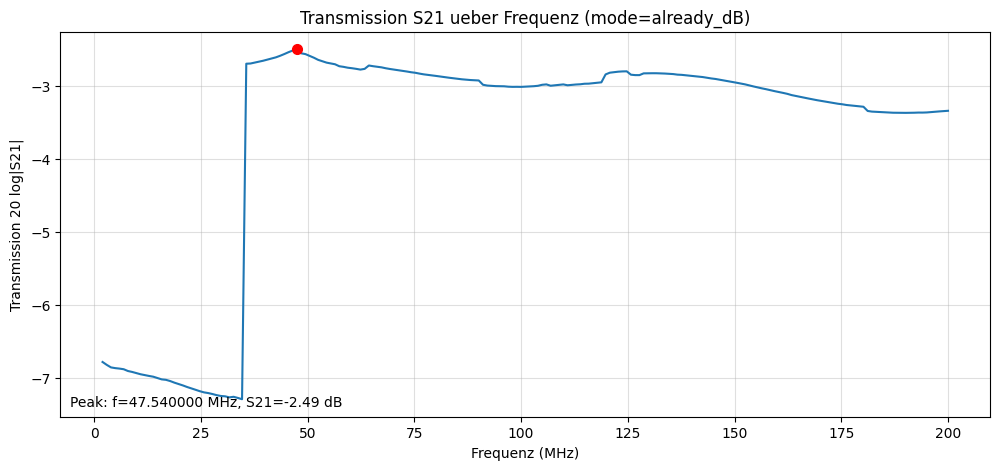

In [ ]:
idn = scpi_query(FPC_IP, FPC_PORT, "*IDN?")
print("Geraet:", idn if idn else "Keine Antwort")

trace_raw = scpi_query(FPC_IP, FPC_PORT, "TRAC:DATA? TRACE1", max_bytes=TRACE_READ_MAX_BYTES)
trace_vals = parse_float_list(trace_raw)
if trace_vals.size < 2:
    raise RuntimeError("TRACE1 leer. Bitte S21-Transmission am Geraet einstellen.")

freq_hz = get_freq_axis(FPC_IP, FPC_PORT, trace_vals.size)
s21_db, s21_mode = to_s21_db(trace_vals)
f_mhz = freq_hz / 1e6

fig = plt.figure(figsize=(12, 6.2))
gs = fig.add_gridspec(2, 1, height_ratios=[1.0, 0.13], hspace=0.35)
ax = fig.add_subplot(gs[0, 0])
ax_slider = fig.add_subplot(gs[1, 0])

ax.plot(f_mhz, s21_db, color="C0", lw=1.5)
ax.set_title(f"Transmission S21 ueber Frequenz (mode={s21_mode})")
ax.set_xlabel("Frequenz (MHz)")
ax.set_ylabel("Transmission 20 log|S21|")
ax.grid(True, alpha=0.4)

idx0 = int(np.argmin(np.abs(f_mhz - np.mean(f_mhz))))
m_s21, = ax.plot([f_mhz[idx0]], [s21_db[idx0]], "o", color="red", ms=7)
info_text = fig.text(0.02, 0.02, "", fontsize=10, ha="left", va="bottom")

slider = Slider(
    ax=ax_slider,
    label="Marker-Frequenz (MHz)",
    valmin=float(f_mhz.min()),
    valmax=float(f_mhz.max()),
    valinit=float(f_mhz[idx0]),
)

def update_marker(f_sel_mhz):
    idx = int(np.argmin(np.abs(f_mhz - f_sel_mhz)))
    m_s21.set_data([f_mhz[idx]], [s21_db[idx]])
    info_text.set_text(f"f={f_mhz[idx]:.6f} MHz | S21={s21_db[idx]:.2f} dB")
    fig.canvas.draw_idle()

slider.on_changed(update_marker)
update_marker(f_mhz[idx0])
plt.show()

Gespeichert: C:\_Git\KT-workspace\lab_suite\labs\03_03_LABOR-3\screenshots\fpc1500_s21_20260323_133357.png


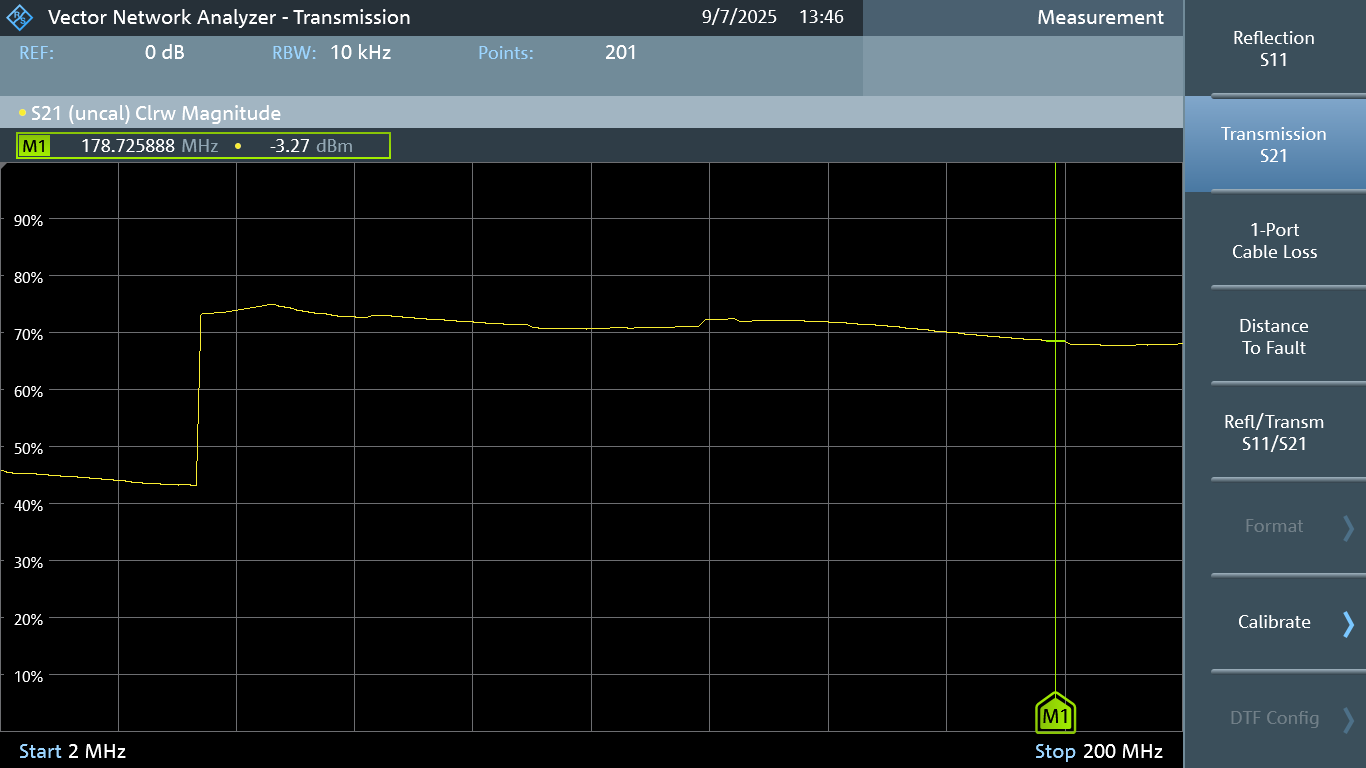

In [8]:
# Screenshot lesen (am Geraet sollte jetzt die S21-Transmission sichtbar sein)
SCREENSHOT_DIR.mkdir(parents=True, exist_ok=True)
err = screenshot_save(FPC_IP, FPC_PORT, SCREENSHOT_FILENAME)
if err:
    print("Screenshot speichern auf dem Geraet fehlgeschlagen:", err)
else:
    png_bytes = screenshot_read(FPC_IP, FPC_PORT, SCREENSHOT_FILENAME)
    if png_bytes:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        out_path = SCREENSHOT_DIR / f"fpc1500_s21_{timestamp}.png"
        out_path.write_bytes(png_bytes)
        print("Gespeichert:", out_path.resolve())
        display(Image(data=png_bytes))
    else:
        print("Screenshot konnte nicht gelesen werden.")